# 02 - Baseline: Ingestão de `.jpg` soltos (Small File Problem)

**Hipótese:** mesmo usando as melhores práticas do `tf.data` (paralelismo + prefetch),
ler **milhares de `.jpg` isolados** do disco gera um gargalo de I/O que deixa a GPu ociosa
(*GPU Starvation*): a CPU fica ocupada decodificando/lendo arquivos e a GPU fica ociosa,
derrubando o **Throughput** (imagens/segundo).

**O que este notebook faz:**
1. Monta um pipeline `tf.data` otimizado lendo `/tf/data/raw_jpg/*.jpg`.
2. Usa uma `ResNet50` (pesos ImageNet) como carga computacional (*dummy*).
3. Roda **3 rodadas** (passadas completas, leitura fria) medindo, via thread paralela
   (`psutil` + `nvidia-ml-py`), CPU%, RAM (GB) e GPU% a cada ~1s.
4. Calcula **Média ± Desvio Padrão** do Throughput, plota os gráficos do *starvation*
   e exporta um `.csv` com o resumo estatístico.

> Roda dentro do contêiner (4GB RAM / 2 vCPUs). Os caminhos usam `/tf/data`.

In [1]:
#importanto as bibliotecas
import os
import time
import threading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import pynvml
import tensorflow as tf

# Configs iniciais do experimento
DATA_GLOB    = "/tf/data/raw_jpg/*.jpg"   # Path das imagens soltas
RESULTS_DIR  = Path("/tf/data/results")   # Saída dos dados do experimento em CSVs 
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = (224, 224)   # Formata pro tamanho de entrada da ResNet50
BATCH_SIZE   = 16          # Quantidade de imagens por lote,muda pra 32 se consegir
N_ROUNDS     = 3            # quantidade de rodadas de teste (para média e desvio padrão)
SAMPLE_EVERY = 1.0          # Intervalo de amostragem do monitor em s

# Evita que o TF reserve 100% da VRAM de uma vez - assim ele aloca conforme necessrio
# Por padrao o TF aloca toda memoria do GPU, msm nao usando, e isso atrapalha o pynvml medir a memoria usada pelo TF
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True) #tenta liga o memory growth, mas pode dar erros se ja tiver alocado a memoria
    except Exception as e: #se der algum erro, printa o erro e continua
        print("memory_growth:", e)

print("TensorFlow:", tf.__version__)
print("GPUs visíveis:", tf.config.list_physical_devices("GPU"))
print("Resultados em:", RESULTS_DIR)
# Pra validar: igonore os erros de cuDNN/cuFFT e os avisos de NUMA, são alarmes falsos, n atrapalha. Se quiser fazer eles sumirem, rode o notebook novamente.
# O que realemnte importa: A versao do TF tem que aparecer, em GPUS visiveis tem que aparecer algo como [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
# A pasta de resultados tem q existir no caminho /tf/data/results.

2026-06-30 14:39:34.377188: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 14:39:34.566999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 14:39:34.633437: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 14:39:34.655059: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 14:39:34.772321: I tensorflow/core/platform/cpu_feature_guar

TensorFlow: 2.17.0
GPUs visíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Resultados em: /tf/data/results


I0000 00:00:1782830377.409411     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782830377.823166     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782830377.829094     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [2]:
# Inicializa o nvidia-ml-py(pynvml) pra pegar os dados de GPU, se n tiver GPU ou se o pynvml n estiver instalado, ignora e continua
try:
    pynvml.nvmlInit()
    GPU_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
    gpu_name = pynvml.nvmlDeviceGetName(GPU_HANDLE)
    if isinstance(gpu_name, bytes): # Pega o handle da GPU e o nome, se o nome for bytes, decodifica pra string
        gpu_name = gpu_name.decode()
    print(f"GPU detectada: {gpu_name}")
except Exception as e:
    GPU_HANDLE = None
    print("pynvml indisponível ou n foi possível achar a GPU, GPU não será monitorada:", e)

GPU detectada: NVIDIA GeForce RTX 5060


In [3]:
# file_path é o caminho do arquivo, ex: /tf/data/raw_jpg/cat.1.jpg
def get_label(file_path):
    # Usa TF strings, pq dentro do tf.data o processamento roda em modo grafo 
    fname = tf.strings.split(file_path, os.sep)[-1] # Pega o nome do arquivo, pelo separator do OS, ex: cat.1.jpg
    is_cat = tf.strings.regex_full_match(tf.strings.lower(fname), "cat.*") # Retorna True se o nome do arquivo começar com "cat" e false se começar com "dog"
    return tf.cast(tf.where(is_cat, 0, 1), tf.float32) # Retorna 0.0 se for gato e 1.0 se for cachorro, como float32


def process_path(file_path):
    label = get_label(file_path) # 0 ou 1 da func de cima
    img = tf.io.read_file(file_path) # Le o arquivo do disco e retorna os bytes - o gargalo fica mais aqui
    img = tf.io.decode_jpeg(img, channels=3) # CPU usa o algoritmo de compressao jpeg nos bytes e transforma em tensor 3D (altura, largura e canais) com 3 canais (RGB)
    img = tf.image.resize(img, IMG_SIZE) # CPU redimensiona pra 224x224 - deve ser aqui q a CPU fica sobrecarregada enquanto a GPU espera
    img = tf.keras.applications.resnet50.preprocess_input(img) # Converte pro formato que a ResNet50 espera: ela subtrai a média de cor de cada canal RGB que foi calculada em todo o ImageNet(df onde foi treinado) e altera pra bgr
    return img, label


def build_dataset(batch_size):
    # shuffle=True espalha a leitura pelo disco -> realça o custo de seek do small-file, pq se fosse sequencial o OS poderia otimizar(read ahead)
    ds = tf.data.Dataset.list_files(DATA_GLOB, shuffle=True) # Cria um dataser c o caminho de todos os arquivos .jpg, embaralhados
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE) # Roda a func process_path pra cada arquivo, em paralelo, usando AUTOTUNE pro CPU atomaticamente decidir quantos threads usar
    ds = ds.batch(batch_size) # Agrupa os arquivos em lotes de 16 imagens, nissso a GPU consegue processar 16 imagens de uma vez q é mais efifciente
    ds = ds.prefetch(tf.data.AUTOTUNE) # C o prefetch, enquanto a GPU processa o lote atual, o CPU já prepara o próximo lote, assim reduz a ociosidade da GPU e CPU
    return ds


ALL_FILES = tf.io.gfile.glob(DATA_GLOB) #retorna uma lista com todos os arquivos .jpg no diretório, usando o glob do tensorflow que funciona em qualquer filesystem
N_FILES = len(ALL_FILES)
if N_FILES == 0:
    raise FileNotFoundError(f"Nenhum .jpg em {DATA_GLOB}. Rode o 01_download.ipynb antes.")
print(f"Total de imagens no diretório: {N_FILES:,}")

Total de imagens no diretório: 328,547


In [4]:
# Modelo "esteira ergométrica": ResNet50 (ImageNet) + cabeça binária.
# include_top=False + pooling='avg' + Dense(1) faz a loss casar com o label
# cat/dog, permitindo um train_on_batch real (forward + backward) na GPU.
def build_model():
    base = tf.keras.applications.ResNet50( # Chama o modelo
        weights="imagenet", include_top=False, # Carrega os pesos ja treinados do ImageNet(camadas convolucionais +1000 classificações) e o include_top remove a cabeça do modelo, que é a parte final que faz a classificação, pq vamos colocar uma cabeça nova
        input_shape=(*IMG_SIZE, 3), pooling="avg", #Iput shape define o tamanho das entradas no modelo e pooling="avg" faz a média global dos mapas de ativação da camada convolucional, transformando o tensor 3D(pilha de matrizes com os padrões reconhecidos) em um vetor 1D, claculando a media de cada mapa
    )
    out = tf.keras.layers.Dense(1, activation="sigmoid")(base.output) # Recebe o tensor 1D da media de cada um dos 2048 mapas de ativação da ResNet50 e passa ra um neuronio c 1 de densidade, retornando 1 valor por imagem e sigmoid transforma o valor em uma probabilidade entre 0 e 1, que é o que queremos pra classificar gato ou cachorro
    model = tf.keras.Model(base.input, out) # Define q a entrada vai ser do modelo vai ser o vetor 3d(batch, h, w, c) e a saída vai ser o vetor 1d(batch, 1) com a probabilidade de ser cachorro
    model.compile(optimizer="sgd", loss="binary_crossentropy") # Compila o modelo, definindo como vai comparar as 64 possibilidades com os labels e como atualizar os pesos da rede, usando o otimizador SGD e a função de perda binary_crossentropy, que é a mais adequada pra problemas de classificação binária
    return model


model = build_model()
print("Modelo pronto. Parâmetros:", f"{model.count_params():,}")

I0000 00:00:1782830406.071510     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782830406.083734     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782830406.088091     172 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1782830406.204354     172 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Modelo pronto. Parâmetros: 23,589,761


In [6]:
# ---------------------------------------------------------------------------
# Thread de monitoramento: amostra CPU%, RAM e GPU% a cada SAMPLE_EVERY s.
# ---------------------------------------------------------------------------
# IMPORTANTE: dentro do contêiner Docker, `psutil.cpu_percent()` continua
# medindo a média sobre os 12 threads do HOST -- e nao sobre os 2 vCPUs que
# o cgroup nos da. Resultado: 2 vCPUs saturados a 100% aparecem como ~17%
# no grafico, mascarando o gargalo de CPU. A correcao abaixo le o cgroup
# (v1 ou v2) pra descobrir quantos vCPUs o conteiner realmente tem e
# normaliza a metrica de CPU do PROCESSO por esse limite -- assim a coluna
# `cpu_pct` passa a refletir saturacao real (0-100 sobre os vCPUs do conteiner).

import os


def detect_container_cpu_quota():
    """Numero de vCPUs disponiveis ao conteiner (float)."""
    # cgroup v2
    try:
        with open("/sys/fs/cgroup/cpu.max") as f:
            quota_str, period_str = f.read().strip().split()
        if quota_str != "max":
            return float(quota_str) / float(period_str)
    except (FileNotFoundError, OSError, ValueError):
        pass
    # cgroup v1
    try:
        with open("/sys/fs/cgroup/cpu/cpu.cfs_quota_us") as f:
            quota = int(f.read().strip())
        with open("/sys/fs/cgroup/cpu/cpu.cfs_period_us") as f:
            period = int(f.read().strip())
        if quota > 0:
            return quota / period
    except (FileNotFoundError, OSError, ValueError):
        pass
    # Fallback: CPUs visiveis ao processo (cpuset) ou logicos
    try:
        return float(len(os.sched_getaffinity(0)))
    except (AttributeError, OSError):
        return float(os.cpu_count() or 1)


N_HOST_CPUS      = psutil.cpu_count(logical=True)
N_CONTAINER_CPUS = detect_container_cpu_quota()
print(f"CPUs do host (psutil enxerga):    {N_HOST_CPUS}")
print(f"vCPUs do conteiner (cgroup):      {N_CONTAINER_CPUS}")
print(f"Fator de escala host/conteiner:   {N_HOST_CPUS / N_CONTAINER_CPUS:.2f}x")
print("=> coluna `cpu_pct` agora representa % sobre os vCPUs do conteiner.")


class ResourceMonitor(threading.Thread):
    """
    Captura a cada `interval` s:

      cpu_pct       % de uso dos vCPUs do CONTEINER (0-100).
                    METRICA PRINCIPAL: se passar de ~85% durante o pipeline,
                    a CPU do conteiner esta saturada (gargalo de I/O+decode
                    confirmado -> Small File Problem visivel).
      cpu_pct_host  % medio do HOST (12 threads). So pra referencia/debug;
                    NAO usar como prova de starvation.
      proc_cpu_raw  % do processo Python sobre 1 vCPU; pode passar de 100
                    (ex.: 180% = ~1.8 vCPUs usados pelo processo).
      ram_used_gb   RAM usada no sistema.
      proc_rss_gb   RAM residente do processo Python.
      gpu_util_pct  Utilizacao da GPU (pynvml).
      gpu_mem_gb    Memoria VRAM ocupada.
    """

    def __init__(self, gpu_handle, interval=1.0,
                 n_container_cpus=N_CONTAINER_CPUS):
        super().__init__(daemon=True)
        self.handle = gpu_handle
        self.interval = interval
        # Evita divisao por zero se a deteccao falhar
        self.n_container_cpus = max(float(n_container_cpus), 1e-6)
        self._stop_event = threading.Event()
        self.samples = []
        self.proc = psutil.Process()

    def run(self):
        psutil.cpu_percent(None)        # prime: 1a leitura e descartavel
        self.proc.cpu_percent(None)
        t_start = time.time()
        while not self._stop_event.is_set():
            cpu_host     = psutil.cpu_percent(None)         # % media do host (12 threads)
            proc_cpu_raw = self.proc.cpu_percent(None)      # % do processo (pode > 100)
            # Normaliza pelo numero de vCPUs do conteiner:
            cpu_container = min(proc_cpu_raw / self.n_container_cpus, 100.0)

            vm = psutil.virtual_memory()
            ram_used_gb  = vm.used / (1024 ** 3)
            proc_rss_gb  = self.proc.memory_info().rss / (1024 ** 3)

            gpu_util, gpu_mem_gb = np.nan, np.nan
            if self.handle is not None:
                try:
                    gpu_util   = float(pynvml.nvmlDeviceGetUtilizationRates(self.handle).gpu)
                    gpu_mem_gb = pynvml.nvmlDeviceGetMemoryInfo(self.handle).used / (1024 ** 3)
                except Exception:
                    pass

            self.samples.append({
                "t_rel":         time.time() - t_start,
                "cpu_pct":       cpu_container,   # METRICA PRINCIPAL (escala do conteiner)
                "cpu_pct_host":  cpu_host,        # contexto (escala do host)
                "proc_cpu_raw":  proc_cpu_raw,    # bruto do processo (pode > 100)
                "ram_used_gb":   ram_used_gb,
                "proc_rss_gb":   proc_rss_gb,
                "gpu_util_pct":  gpu_util,
                "gpu_mem_gb":    gpu_mem_gb,
            })
            self._stop_event.wait(self.interval)

    def stop(self):
        self._stop_event.set()
        self.join()
        return pd.DataFrame(self.samples)

CPUs do host (psutil enxerga):    12
vCPUs do conteiner (cgroup):      2.0
Fator de escala host/conteiner:   6.00x
=> coluna `cpu_pct` agora representa % sobre os vCPUs do conteiner.


In [6]:
round_summaries = []   # 1 linha por rodada (métricas agregadas)
raw_samples = []       # série temporal de todas as amostras (p/ gráficos)

for r in range(1, N_ROUNDS + 1): # Treina o modelo N_ROUNDS vezes, cada vez com um dataset novo (força a leitura do disco, simulando cold start)
    print(f"\n===== Rodada {r}/{N_ROUNDS} =====")
    ds = build_dataset(BATCH_SIZE)     # pipeline novo -> força reler do disco

    monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
    monitor.start()

    n_images = 0
    t0 = time.time()
    
    for x, y in ds: # x é o tensro4d e y é o tensor 1d com os labels
        model.train_on_batch(x, y)     # forward + backward (carga na GPU)
        n_images += int(x.shape[0])    # Usa isso pra calcular o throughput, pq o último lote pode ter menos de BATCH_SIZE imagens
    elapsed = time.time() - t0

    df_s = monitor.stop()
    df_s["round"] = r
    raw_samples.append(df_s)

    throughput = n_images / elapsed
    summary = {
        "round": r,
        "n_images": n_images,
        "round_time_s": elapsed,
        "throughput_img_s": throughput,
        "cpu_mean_pct": df_s["cpu_pct"].mean(),
        "cpu_max_pct": df_s["cpu_pct"].max(),
        "ram_peak_gb": df_s["ram_used_gb"].max(),
        #add media do uso de ram?
        "proc_rss_peak_gb": df_s["proc_rss_gb"].max(),
        "gpu_util_mean_pct": df_s["gpu_util_pct"].mean(),
        "gpu_util_max_pct": df_s["gpu_util_pct"].max(),
        "gpu_mem_peak_gb": df_s["gpu_mem_gb"].max(), #media?
    }
    round_summaries.append(summary)
    print(f"  imagens={n_images:,} | tempo={elapsed:.1f}s | "
          f"throughput={throughput:.1f} img/s | "
          f"CPU médio={summary['cpu_mean_pct']:.0f}% | "
          f"GPU média={summary['gpu_util_mean_pct']:.0f}%")

summary_df = pd.DataFrame(round_summaries)
raw_df = pd.concat(raw_samples, ignore_index=True)
summary_df


===== Rodada 1/3 =====


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target' (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  imagens=328,547 | tempo=1507.2s | throughput=218.0 img/s | CPU médio=69% | GPU média=88%

===== Rodada 2/3 =====


2026-06-30 08:18:01.467837: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  imagens=328,547 | tempo=1490.5s | throughput=220.4 img/s | CPU médio=69% | GPU média=89%

===== Rodada 3/3 =====
  imagens=328,547 | tempo=1490.2s | throughput=220.5 img/s | CPU médio=69% | GPU média=89%


,round,n_images,round_time_s,throughput_img_s,cpu_mean_pct,cpu_max_pct,ram_peak_gb,proc_rss_peak_gb,gpu_util_mean_pct,gpu_util_max_pct,gpu_mem_peak_gb
0,1,328547,1507.220173,217.982088,68.610518,70.00,7.786720,2.454453,88.254811,98.0,4.047241
1,2,328547,1490.478425,220.430564,68.837383,71.50,6.364887,2.571518,88.614094,93.0,3.679749
2,3,328547,1490.166569,220.476695,68.856174,72.45,6.321686,2.578526,88.614094,93.0,3.696777


In [7]:
tp = summary_df["throughput_img_s"].values
tp_mean = tp.mean()
tp_std = tp.std(ddof=1) if len(tp) > 1 else 0.0

stats = {
    "pipeline": "baseline_jpg",
    "n_rounds": N_ROUNDS,
    "batch_size": BATCH_SIZE,
    "n_images": int(summary_df["n_images"].iloc[0]),
    "throughput_mean_img_s": tp_mean,
    "throughput_std_img_s": tp_std,
    "round_time_mean_s": summary_df["round_time_s"].mean(),
    "cpu_mean_pct": summary_df["cpu_mean_pct"].mean(),
    "gpu_util_mean_pct": summary_df["gpu_util_mean_pct"].mean(),
    "ram_peak_gb": summary_df["ram_peak_gb"].max(),
    "gpu_mem_peak_gb": summary_df["gpu_mem_peak_gb"].max(),
}
stats_df = pd.DataFrame([stats])

summary_df.to_csv(RESULTS_DIR / "baseline_jpg_per_round.csv", index=False)
stats_df.to_csv(RESULTS_DIR / "baseline_jpg_stats.csv", index=False)
raw_df.to_csv(RESULTS_DIR / "baseline_jpg_raw_samples.csv", index=False)

print(f"THROUGHPUT (baseline .jpg): {tp_mean:.1f} ± {tp_std:.1f} img/s")
print(f"GPU média nas rodadas     : {stats['gpu_util_mean_pct']:.0f}%  <- starvation se for baixo")
print(f"CPU média nas rodadas     : {stats['cpu_mean_pct']:.0f}%")
print(f"CSVs salvos em {RESULTS_DIR}")
stats_df

THROUGHPUT (baseline .jpg): 219.6 ± 1.4 img/s
GPU média nas rodadas     : 88%  <- starvation se for baixo
CPU média nas rodadas     : 69%
CSVs salvos em /tf/data/results


,pipeline,n_rounds,batch_size,n_images,throughput_mean_img_s,throughput_std_img_s,round_time_mean_s,cpu_mean_pct,gpu_util_mean_pct,ram_peak_gb,gpu_mem_peak_gb
0,baseline_jpg,3,16,328547,219.629782,1.427132,1495.955056,68.768025,88.494333,7.78672,4.047241


## Gráficos: evidência do *GPU Starvation*

- **Esquerda:** Throughput por rodada com a média ± desvio.
- **Meio:** utilização da GPU ao longo do tempo (deve ficar **baixa**, com vales = GPU faminta).
- **Direita:** CPU médio vs GPU média (CPU alta + GPU baixa = gargalo de I/O na ingestão).

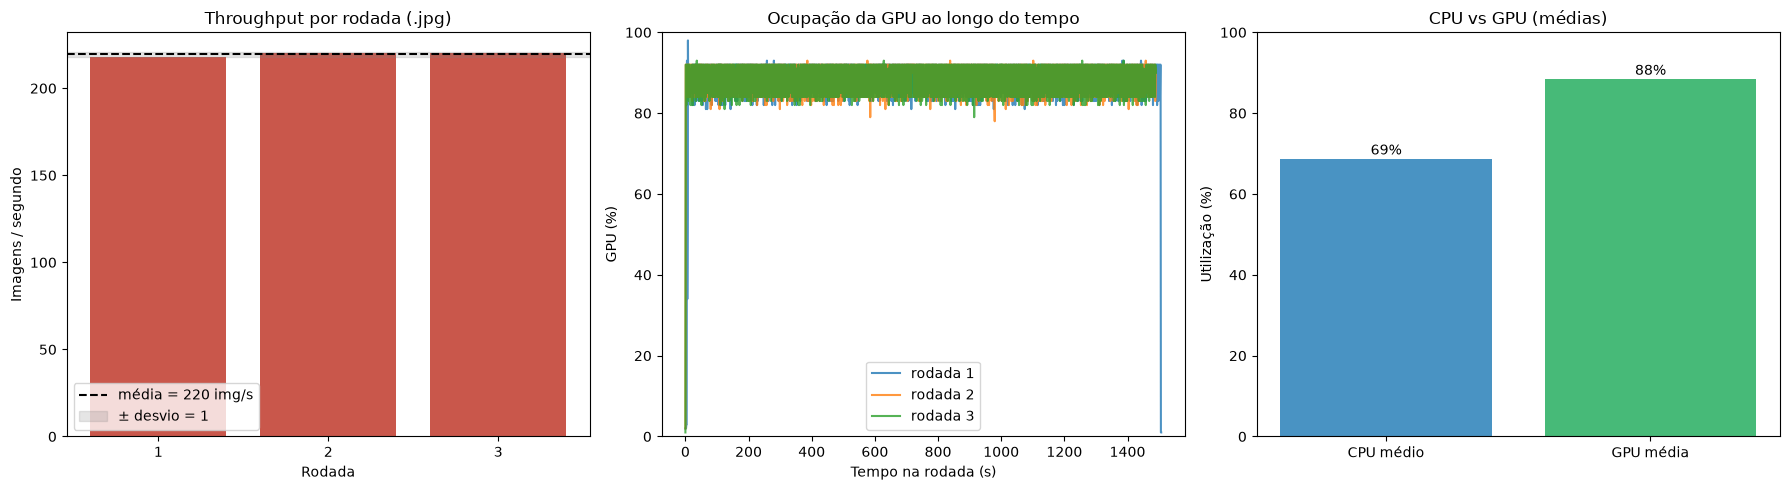

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Throughput por rodada + média/desvio
ax = axes[0]
ax.bar(summary_df["round"].astype(str), summary_df["throughput_img_s"], color="#c0392b", alpha=0.85)
ax.axhline(tp_mean, color="black", ls="--", label=f"média = {tp_mean:.0f} img/s")
ax.axhspan(tp_mean - tp_std, tp_mean + tp_std, color="gray", alpha=0.2, label=f"± desvio = {tp_std:.0f}")
ax.set_title("Throughput por rodada (.jpg)")
ax.set_xlabel("Rodada"); ax.set_ylabel("Imagens / segundo"); ax.legend()

# (2) Utilização da GPU ao longo do tempo, por rodada
ax = axes[1]
for r, g in raw_df.groupby("round"):
    ax.plot(g["t_rel"], g["gpu_util_pct"], label=f"rodada {r}", alpha=0.8)
ax.set_title("Ocupação da GPU ao longo do tempo")
ax.set_xlabel("Tempo na rodada (s)"); ax.set_ylabel("GPU (%)")
ax.set_ylim(0, 100); ax.legend()

# (3) CPU vs GPU médios (o contraste que prova o starvation)
ax = axes[2]
ax.bar(["CPU médio", "GPU média"],
       [stats["cpu_mean_pct"], stats["gpu_util_mean_pct"]],
       color=["#2980b9", "#27ae60"], alpha=0.85)
ax.set_title("CPU vs GPU (médias)")
ax.set_ylabel("Utilização (%)"); ax.set_ylim(0, 100)
for i, v in enumerate([stats["cpu_mean_pct"], stats["gpu_util_mean_pct"]]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_jpg_plots.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
# === TESTE DE TETO (GPU-only): dataset cacheado em RAM -> I/O = zero ===
# Reusa model/tp_mean/stats que ja estao na memoria. NAO re-treina nada.
N_CACHE_IMAGES = 1200      # cabe na RAM do conteiner (~0.7 GB em float32)
N_PASSES       = 5

# Fallback: se o kernel tivesse sido reiniciado, le o baseline do CSV
try:
    tp_mean; stats
except NameError:
    _b = pd.read_csv(RESULTS_DIR / "baseline_jpg_stats.csv").iloc[0]
    tp_mean = float(_b["throughput_mean_img_s"])
    stats = {"gpu_util_mean_pct": float(_b["gpu_util_mean_pct"])}
    print(f"(baseline lido do CSV: {tp_mean:.1f} img/s, GPU {stats['gpu_util_mean_pct']:.0f}%)")

# Mesmo process_path do baseline, mas com .cache() (I/O zero apos a 1a passada)
ds_cache = (tf.data.Dataset.from_tensor_slices(ALL_FILES[:N_CACHE_IMAGES])
            .map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
            .cache()
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

print(f"Aquecendo cache ({N_CACHE_IMAGES} imgs) + GPU (passada nao medida)...")
for x, y in ds_cache:
    model.train_on_batch(x, y)        # 1a passada: enche o cache + warmup, fora do cronometro

monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
monitor.start()
n_images, t0 = 0, time.time()
for _ in range(N_PASSES):
    for x, y in ds_cache:
        model.train_on_batch(x, y)
        n_images += int(x.shape[0])
elapsed = time.time() - t0
df_ceil = monitor.stop()

ceil_throughput = n_images / elapsed
ceil_gpu = df_ceil["gpu_util_pct"].mean()
ceil_cpu = df_ceil["cpu_pct"].mean()
gain = ceil_throughput / tp_mean - 1.0

print(f"\n===== TETO (cacheado, I/O zero) =====")
print(f"Throughput teto : {ceil_throughput:.1f} img/s")
print(f"GPU media       : {ceil_gpu:.0f}%   (max {df_ceil['gpu_util_pct'].max():.0f}%)")
print(f"CPU media        : {ceil_cpu:.0f}%   (deve CAIR vs baseline: sem decode de disco)")
print(f"\n----- Baseline .jpg  ->  Teto cacheado -----")
print(f"Throughput: {tp_mean:6.1f}  ->  {ceil_throughput:6.1f} img/s   ({gain*100:+.0f}%)")
print(f"GPU %     : {stats['gpu_util_mean_pct']:6.0f}  ->  {ceil_gpu:6.0f}")

if gain > 0.15:
    print("\n>> EXISTE FOLGA: a GPU vai alem do baseline sem esperar o disco.")
    print("   Small-file esta segurando o pipeline -> pode seguir p/ o parquet (03/04).")
else:
    print("\n>> SEM FOLGA: throughput ~igual. A GPU ja e' o TETO DURO -> alivie a")
    print("   carga da GPU (forward-only/input menor) antes de comparar com parquet.")

pd.DataFrame([{
    "test": "gpu_ceiling_cached", "n_cache_images": N_CACHE_IMAGES, "n_passes": N_PASSES,
    "batch_size": BATCH_SIZE, "ceil_throughput_img_s": ceil_throughput,
    "ceil_gpu_mean_pct": ceil_gpu, "ceil_cpu_mean_pct": ceil_cpu,
    "baseline_throughput_img_s": tp_mean, "baseline_gpu_mean_pct": stats["gpu_util_mean_pct"],
    "gain_vs_baseline_pct": gain * 100,
}]).to_csv(RESULTS_DIR / "baseline_jpg_gpu_ceiling.csv", index=False)

Aquecendo cache (1200 imgs) + GPU (passada nao medida)...


2026-06-30 14:42:32.008649: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



===== TETO (cacheado, I/O zero) =====
Throughput teto : 222.4 img/s
GPU media       : 89%   (max 93%)
CPU media        : 51%   (deve CAIR vs baseline: sem decode de disco)

----- Baseline .jpg  ->  Teto cacheado -----
Throughput:  219.6  ->   222.4 img/s   (+1%)
GPU %     :     88  ->      89

>> SEM FOLGA: throughput ~igual. A GPU ja e' o TETO DURO -> alivie a
   carga da GPU (forward-only/input menor) antes de comparar com parquet.


In [9]:
# === INGESTAO PURA (sem modelo): teto real de leitura+decode do jpg ===
# Tira a GPU da jogada: so itera o tf.data e conta. Revela o I/O+decode
# que o train estava escondendo. Mantem shuffle p/ provocar seeks de small-file.
N_SAMPLE = 20000

ds_io = build_dataset(BATCH_SIZE)
monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
monitor.start()
n_images, t0 = 0, time.time()
for x, y in ds_io.take(N_SAMPLE // BATCH_SIZE):
    n_images += int(x.shape[0])          # SO consome, nao treina
elapsed = time.time() - t0
df_io = monitor.stop()

io_tp = n_images / elapsed
print(f"\n===== INGESTAO PURA jpg (sem modelo) =====")
print(f"Throughput ingestao : {io_tp:.1f} img/s")
print(f"CPU media           : {df_io['cpu_pct'].mean():.0f}%  (max {df_io['cpu_pct'].max():.0f}%)  <- deve SATURAR (~100%)")
print(f"GPU media           : {df_io['gpu_util_pct'].mean():.0f}%  <- deve ser ~0 (GPU ociosa)")
print(f"\nGPU-train cap = {tp_mean:.0f} img/s  |  ingestao pura jpg = {io_tp:.0f} img/s")

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f


===== INGESTAO PURA jpg (sem modelo) =====
Throughput ingestao : 1134.0 img/s
CPU media           : 94%  (max 100%)  <- deve SATURAR (~100%)
GPU media           : 3%  <- deve ser ~0 (GPU ociosa)

GPU-train cap = 220 img/s  |  ingestao pura jpg = 1134 img/s


In [10]:
# === INGESTAO COLD: gargalo do jpg e' DISCO (small-file) ou CPU (decode)? ===
# Passa pelo dataset INTEIRO (>RAM) p/ forcar eviccao de cache e expor o seek
# real dos small-files. shuffle=True = pior caso de seek. Sem modelo. ~5-7 min.
ds_cold = build_dataset(BATCH_SIZE)
monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY)
monitor.start()
n_images, t0 = 0, time.time()
for x, y in ds_cold:
    n_images += int(x.shape[0])
elapsed = time.time() - t0
df_cold = monitor.stop()

cold_tp  = n_images / elapsed
cold_cpu = df_cold["cpu_pct"].mean()
print(f"\n===== INGESTAO COLD jpg (dataset inteiro, sem modelo) =====")
print(f"Imagens     : {n_images:,}")
print(f"Throughput  : {cold_tp:.1f} img/s")
print(f"CPU media   : {cold_cpu:.0f}%  (max {df_cold['cpu_pct'].max():.0f}%)")
print(f"\nWarm (20k) = 1134 img/s  ->  Cold (full) = {cold_tp:.0f} img/s")
if cold_cpu > 80:
    print(">> CPU ainda SATURADA -> gargalo e' DECODE (CPU), nao disco. Small-file nao")
    print("   morde nesse NVMe; parquet-com-bytes-jpeg ganha pouco -> rever ETL/design.")
else:
    print(">> CPU CAIU (I/O-wait) -> gargalo e' DISCO/seek de small-file. Tese confirmada;")
    print("   parquet sequencial deve dar ganho grande.")


===== INGESTAO COLD jpg (dataset inteiro, sem modelo) =====
Imagens     : 328,547
Throughput  : 1142.9 img/s
CPU media   : 99%  (max 100%)

Warm (20k) = 1134 img/s  ->  Cold (full) = 1143 img/s
>> CPU ainda SATURADA -> gargalo e' DECODE (CPU), nao disco. Small-file nao
   morde nesse NVMe; parquet-com-bytes-jpeg ganha pouco -> rever ETL/design.


In [11]:
# Leitura PURA do SSD: bytes crus, SEM decode -> isola o teto do disco
ds_read = (tf.data.Dataset.list_files(DATA_GLOB, shuffle=True)
           .map(tf.io.read_file, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
monitor = ResourceMonitor(GPU_HANDLE, interval=SAMPLE_EVERY); monitor.start()
n, t0 = 0, time.time()
for b in ds_read.take(60000 // BATCH_SIZE):
    n += int(b.shape[0])
elapsed = time.time() - t0
df = monitor.stop()
print(f"Leitura pura SSD (sem decode): {n/elapsed:.0f} img/s | CPU {df['cpu_pct'].mean():.0f}%")

Leitura pura SSD (sem decode): 34615 img/s | CPU 24%
